2026-02-23 11:30:45.067939: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-23 11:30:45.202167: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-23 11:30:49.693241: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-23 11:30:56.549435: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

553467096/553467096 ━━━━━━━━━━━━━━━━━━━━ 57s 0us/step
102967424/102967424 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step


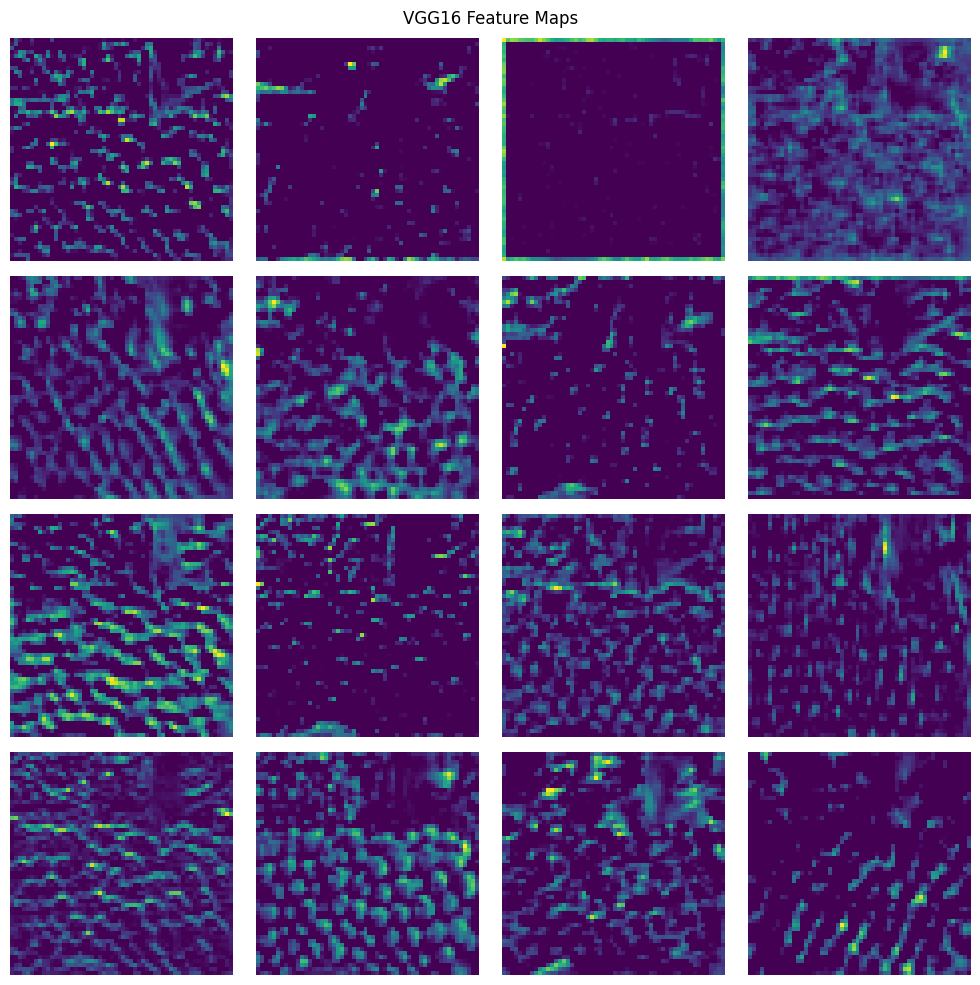

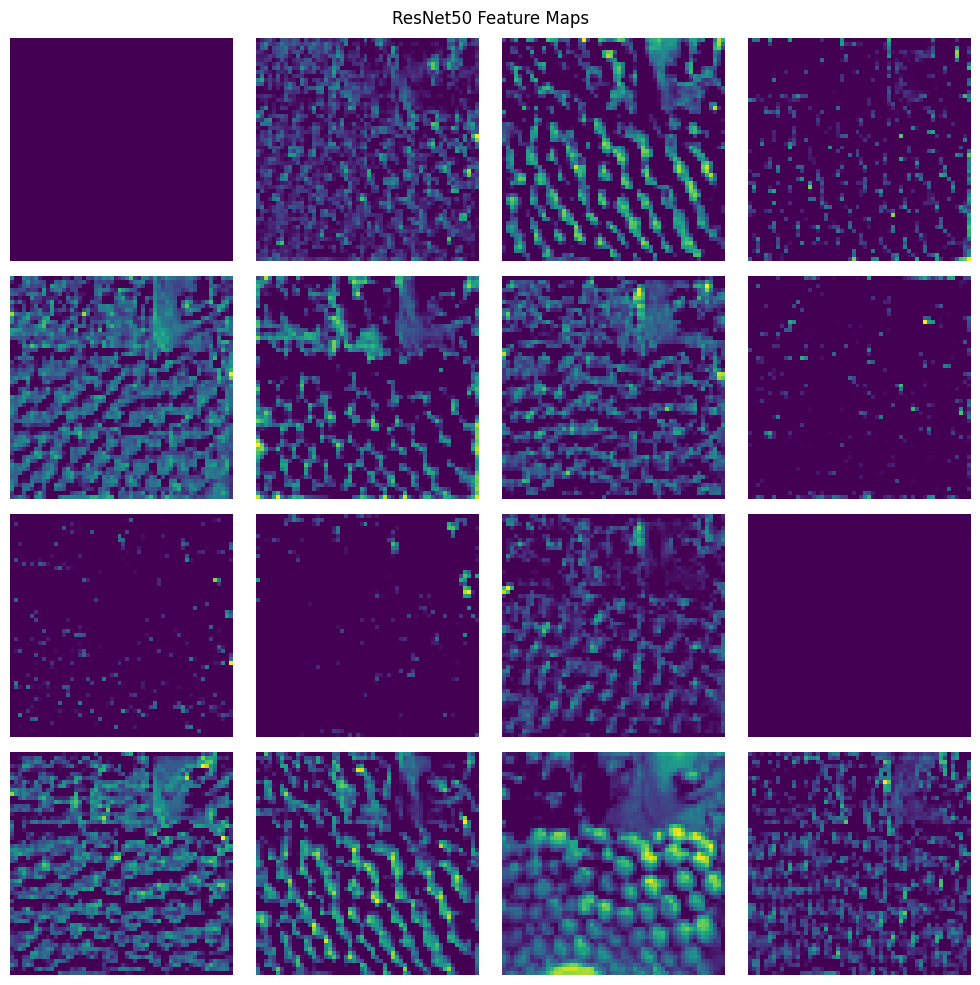

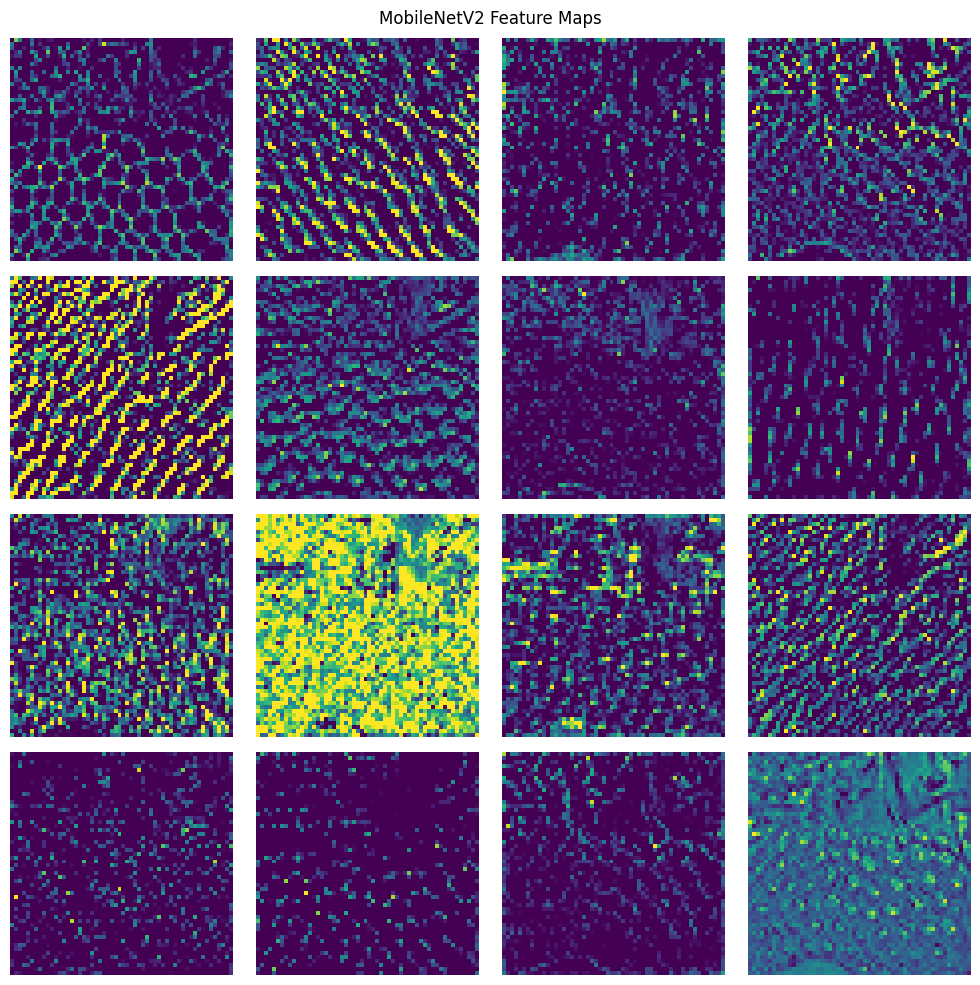

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobile_preprocess
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model

# 1. Load and Preprocess Image

IMG_PATH = "Image/a.jpg"

img = image.load_img(IMG_PATH, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# 2. Load Pretrained Models

vgg = VGG16(weights='imagenet')
resnet = ResNet50(weights='imagenet')
mobilenet = MobileNetV2(weights='imagenet')

# 3. Select Convolutional Layers

vgg_layer = vgg.get_layer("block3_conv1").output
resnet_layer = resnet.get_layer("conv2_block1_out").output
mobile_layer = mobilenet.get_layer("block_3_expand_relu").output

vgg_model = Model(inputs=vgg.input, outputs=vgg_layer)
resnet_model = Model(inputs=resnet.input, outputs=resnet_layer)
mobile_model = Model(inputs=mobilenet.input, outputs=mobile_layer)

# 4. Get Feature Maps

vgg_features = vgg_model.predict(vgg_preprocess(img_array.copy()))
resnet_features = resnet_model.predict(resnet_preprocess(img_array.copy()))
mobile_features = mobile_model.predict(mobile_preprocess(img_array.copy()))

# 5. Function to Plot Feature Maps

def plot_feature_maps(feature_maps, title, num_filters=16):
    plt.figure(figsize=(10,10))
    for i in range(num_filters):
        plt.subplot(4,4,i+1)
        plt.imshow(feature_maps[0,:,:,i], cmap='viridis')
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

# 6. Visualize

plot_feature_maps(vgg_features, "VGG16 Feature Maps")
plot_feature_maps(resnet_features, "ResNet50 Feature Maps")
plot_feature_maps(mobile_features, "MobileNetV2 Feature Maps")